In [1]:
# Part 4
# 4.1 - Deutsch-Jozsa Algorithm, used to identify functions as constant or balanced essentially
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
def deutsch_jozsa_oracle(n, oracle_type="balanced"):
    """Create a Deutsch-Jozsa oracle on n input qubits and 1 output qubit."""
    oracle = QuantumCircuit(n + 1, name=f"{oracle_type}_oracle")

    output_qubit = n

    if oracle_type == "constant_zero":
        # f(x) = 0 for every x.
        # The oracle maps |x>|y> to |x>|y XOR 0>, so it does nothing.
        pass

    elif oracle_type == "constant_one":
        # f(x) = 1 for every x.
        # The oracle maps |x>|y> to |x>|y XOR 1>, so it flips the output qubit.
        oracle.x(output_qubit)

    elif oracle_type == "balanced":
        # f(x) = x_0 XOR x_1 XOR ... XOR x_{n-1}.
        # CNOT gates from each input qubit to the output qubit compute this parity.
        for input_qubit in range(n):
            oracle.cx(input_qubit, output_qubit)

    else:
        raise ValueError("oracle_type must be 'constant_zero', 'constant_one', or 'balanced'.")

    return oracle

In [3]:
def build_deutsch_jozsa_circuit(n, oracle):
    """Build the full Deutsch-Jozsa circuit for a given oracle."""
    qc = QuantumCircuit(n + 1, n)

    input_qubits = range(n)
    output_qubit = n

    # Step 1: Put the output qubit into |1>.
    qc.x(output_qubit)

    # Step 2: Apply Hadamard gates to input qubits and the output qubit.
    qc.h(input_qubits)
    qc.h(output_qubit)

    # Step 3: Apply the oracle once.
    qc.append(oracle.to_gate(), range(n + 1))

    # Step 4: Apply Hadamard gates again to the input qubits only.
    qc.h(input_qubits)

    # Step 5: Measure the input qubits.
    qc.measure(input_qubits, range(n))

    return qc

In [4]:
def run_on_simulator(qc, shots=1024):
    """Run a measured quantum circuit on the local Aer simulator."""
    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    return result.get_counts()

{'000': 1024}


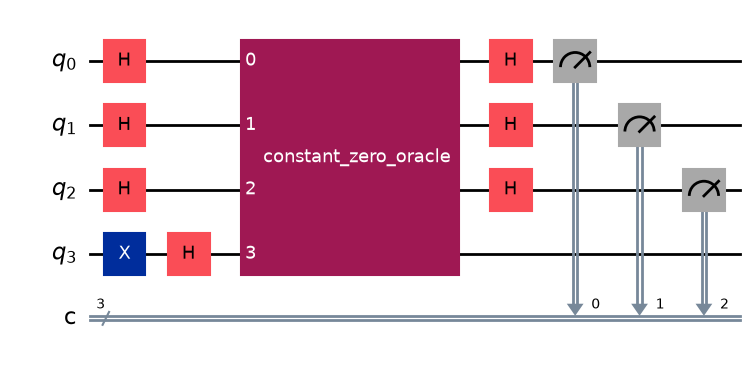

In [5]:
# test it!
n = 3

constant_oracle = deutsch_jozsa_oracle(n, oracle_type="constant_zero")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=1024)
print(constant_counts)

constant_circuit.draw("mpl")

{'111': 1024}


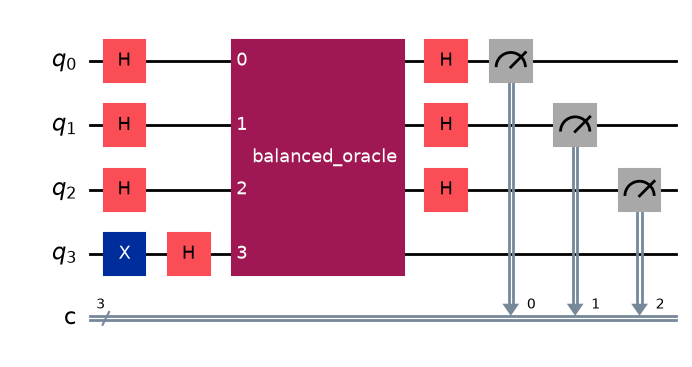

In [7]:
balanced_oracle = deutsch_jozsa_oracle(n, oracle_type="balanced")
balanced_circuit = build_deutsch_jozsa_circuit(n, balanced_oracle)

balanced_counts = run_on_simulator(balanced_circuit, shots=1024)
print(balanced_counts)

balanced_circuit.draw("mpl") # output is NOT 000, so indicative of balanced

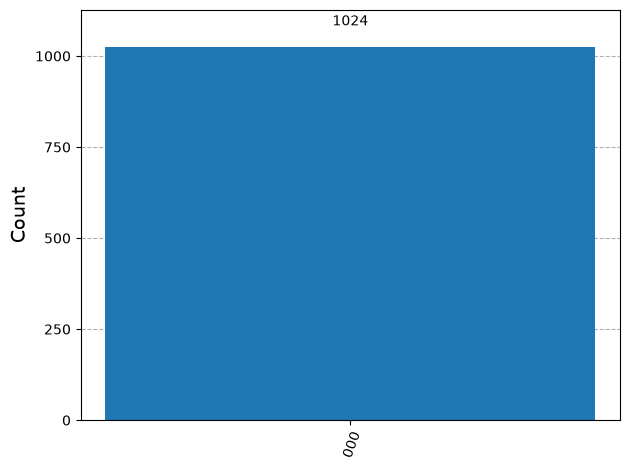

In [8]:
plot_histogram(constant_counts)

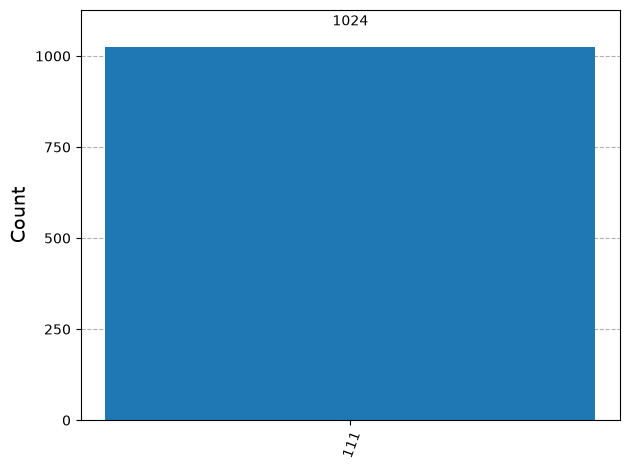

In [9]:
plot_histogram(balanced_counts)

In [10]:
# FULL example
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


def deutsch_jozsa_oracle(n, oracle_type="balanced"):
    """Create a Deutsch-Jozsa oracle on n input qubits and 1 output qubit."""
    oracle = QuantumCircuit(n + 1, name=f"{oracle_type}_oracle")
    output_qubit = n

    if oracle_type == "constant_zero":
        pass

    elif oracle_type == "constant_one":
        oracle.x(output_qubit)

    elif oracle_type == "balanced":
        for input_qubit in range(n):
            oracle.cx(input_qubit, output_qubit)

    else:
        raise ValueError("oracle_type must be 'constant_zero', 'constant_one', or 'balanced'.")

    return oracle


def build_deutsch_jozsa_circuit(n, oracle):
    """Build the full Deutsch-Jozsa circuit for a given oracle."""
    qc = QuantumCircuit(n + 1, n)
    input_qubits = range(n)
    output_qubit = n

    qc.x(output_qubit)
    qc.h(input_qubits)
    qc.h(output_qubit)
    qc.append(oracle.to_gate(), range(n + 1))
    qc.h(input_qubits)
    qc.measure(input_qubits, range(n))

    return qc


def run_on_simulator(qc, shots=1024):
    """Run a measured quantum circuit on the local Aer simulator."""
    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    return result.get_counts()


n = 3

constant_oracle = deutsch_jozsa_oracle(n, "constant_zero")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)
constant_counts = run_on_simulator(constant_circuit)
print("Constant function counts:")
print(constant_counts)

balanced_oracle = deutsch_jozsa_oracle(n, "balanced")
balanced_circuit = build_deutsch_jozsa_circuit(n, balanced_oracle)
balanced_counts = run_on_simulator(balanced_circuit)
print("Balanced function counts:")
print(balanced_counts)

Constant function counts:
{'000': 1024}
Balanced function counts:
{'111': 1024}


In [11]:
#PRACTICE TASKS

{'00': 1024}


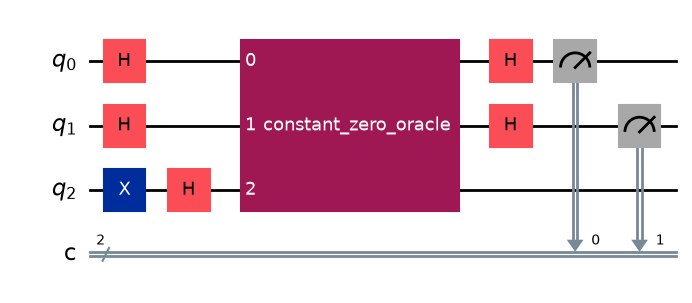

In [12]:
# constant zero, n = 2
n = 2

constant_oracle = deutsch_jozsa_oracle(n, oracle_type="constant_zero")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=1024)
print(constant_counts)

constant_circuit.draw("mpl")

{'00': 1024}


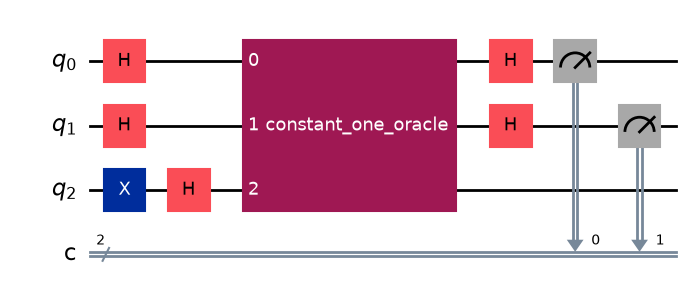

In [13]:
# constant one, n = 2
n = 2

constant_oracle = deutsch_jozsa_oracle(n, oracle_type="constant_one")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=1024)
print(constant_counts)

constant_circuit.draw("mpl")

{'11': 1024}


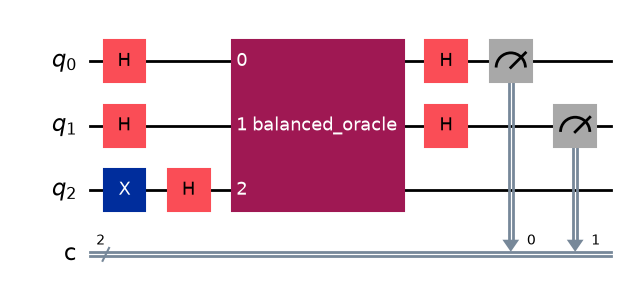

In [14]:
# balanced, n = 2
n = 2

constant_oracle = deutsch_jozsa_oracle(n, oracle_type="balanced")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=1024)
print(constant_counts)

constant_circuit.draw("mpl")

{'000': 4096}


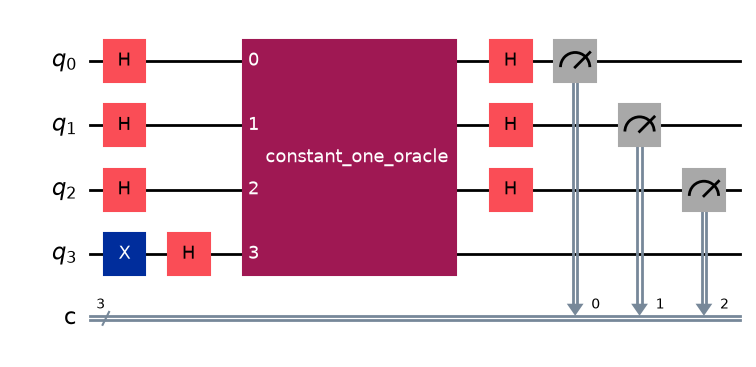

In [16]:
# constant one, n = 3
n = 3

constant_oracle = deutsch_jozsa_oracle(n, oracle_type="constant_one")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=4096)
print(constant_counts)

constant_circuit.draw("mpl")

In [18]:
# only uses 1 qubit as the control for balanced type
def deutsch_jozsa_oracle_variant(n, oracle_type="balanced"):
    """Create a Deutsch-Jozsa oracle on n input qubits and 1 output qubit."""
    oracle = QuantumCircuit(n + 1, name=f"{oracle_type}_oracle")

    output_qubit = n

    if oracle_type == "constant_zero":
        # f(x) = 0 for every x.
        # The oracle maps |x>|y> to |x>|y XOR 0>, so it does nothing.
        pass

    elif oracle_type == "constant_one":
        # f(x) = 1 for every x.
        # The oracle maps |x>|y> to |x>|y XOR 1>, so it flips the output qubit.
        oracle.x(output_qubit)

    elif oracle_type == "balanced":
        # f(x) = x_0 XOR x_1 XOR ... XOR x_{n-1}.
        # CNOT gates from each input qubit to the output qubit compute this parity.
        for input_qubit in range(1): # now only uses 1 qubit for controlling
            oracle.cx(input_qubit, output_qubit)

    else:
        raise ValueError("oracle_type must be 'constant_zero', 'constant_one', or 'balanced'.")

    return oracle

{'001': 1024}


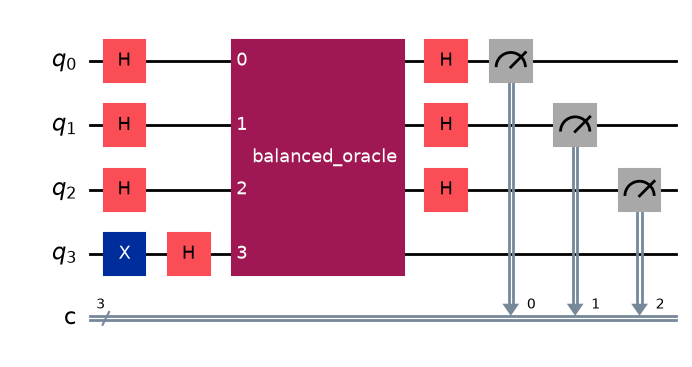

In [19]:
# balanced variant, n = 3, output was 001 instead of 111, so technically works? unsure if this is what they want
n = 3

constant_oracle = deutsch_jozsa_oracle_variant(n, oracle_type="balanced")
constant_circuit = build_deutsch_jozsa_circuit(n, constant_oracle)

constant_counts = run_on_simulator(constant_circuit, shots=1024)
print(constant_counts)

constant_circuit.draw("mpl")